In [4]:
from __future__ import annotations

import numpy.typing as npt
import torch

from cs336_basics.bpe_tokenizer import BpeTokenizer
from cs336_basics.LanguageModel import LanguageModel
from cs336_basics.AdamW import AdamW
from cs336_basics.utils import run_get_batch, run_get_lr_cosine_schedule, run_cross_entropy, run_gradient_clipping, run_save_checkpoint, run_load_checkpoint

import numpy as np
from cs336_basics.pretokenization_example import find_chunk_boundaries
import time

In [5]:
vocab_size = 10000
context_length = 256
d_model = 512
num_layers = 4
num_heads = 16
d_ff = 1344

batch_size=32
device='cpu'
dtype=torch.bfloat16

rope_theta = 10000
betas = [0.9, 0.95]
weight_decay = 1


iterations = 10000

# learning rate hyperparam
max_lr = 1e-2
min_lr = 1e-5
warmup_iters = iterations * 0.2
cosine_cycle_iters = iterations * 0.9
max_l2_norm = 1


In [6]:

# build train data from tokenizer
merges_filepath = 'output/TinyStoriesV2-GPT4-train-heap-merges.json'
vocab_filepath = 'output/TinyStoriesV2-GPT4-train-heap-vocab.json'

print('loading bpe tokenizer')
tokenizer = BpeTokenizer.from_files(vocab_filepath, merges_filepath, ['<|endoftext|>'])

loading bpe tokenizer


In [7]:
len(tokenizer.vocab_dict)

10000

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
lm = LanguageModel(vocab_size, context_length, d_model, num_layers, num_heads, d_ff, rope_theta, device=device, dtype=dtype)
lm = lm.to(device)
optimizer = AdamW(lm.parameters(), betas, weight_decay, lr=1e-3, eps=1e-8)


# create data

In [7]:

# input_path = "data/TinyStoriesV2-GPT4-train.txt"
# output_path = "data/train.bin"

# with open(input_path, "rb") as f, open(output_path, "wb") as out:
#     num_chunks = 40

#     boundaries = find_chunk_boundaries(
#         f,
#         num_chunks,
#         b"<|endoftext|>"
#     )

#     chunk = 1
#     for start, end in zip(boundaries[:-1], boundaries[1:]):
#         print(f'=== chunk {chunk} ===')
#         f.seek(start)

#         text = f.read(end - start).decode("utf-8")

#         token_ids = tokenizer.encode(text)

#         np.asarray(
#             token_ids,
#             dtype=np.uint16
#         ).tofile(out)
#         chunk += 1

In [8]:

# input_path = "data/TinyStoriesV2-GPT4-valid.txt"
# output_path = "data/valid.bin"

# with open(input_path, "rb") as f, open(output_path, "wb") as out:
#     num_chunks = 20

#     boundaries = find_chunk_boundaries(
#         f,
#         num_chunks,
#         b"<|endoftext|>"
#     )

#     chunk = 1
#     for start, end in zip(boundaries[:-1], boundaries[1:]):
#         print(f'=== chunk {chunk} ===')
#         f.seek(start)

#         text = f.read(end - start).decode("utf-8")

#         token_ids = tokenizer.encode(text)

#         np.asarray(
#             token_ids,
#             dtype=np.uint16
#         ).tofile(out)
#         chunk += 1

# train

In [43]:
losses = []

valid_data = np.memmap(
    "data/valid.bin",
    dtype=np.uint16,
    mode="r"
)

train_data = np.memmap(
    "data/train.bin",
    dtype=np.uint16,
    mode="r"
)

# val_data = np.load("valid.npy", mmap_mode="r")
logs = {
    "iteration": [],
    "tokens_processed": [],
    "train_loss": [],
    "val_loss": [],
    "val_iteration": [],
    "lr": [],
    "iter_time": [],
}

In [12]:
iterations=100000

In [ ]:
# lm model
for it in range(iterations):

    # ===========
    # Train 
    # ===========
    lm.train()

    start_time = time.perf_counter()
    optimizer.zero_grad()

    indices, labels = run_get_batch(train_data, batch_size, context_length, device=device)
    output = lm.forward(indices, context_length)

    loss = run_cross_entropy(output, labels)
    if (it+1) % 100 == 0:
        print(f'========= itr {it} =========')
        print(loss.item())

    loss.backward()

    lr = run_get_lr_cosine_schedule(it, max_lr, min_lr, warmup_iters, cosine_cycle_iters)
    for group in optimizer.param_groups:
        group["lr"] = lr

    run_gradient_clipping(lm.parameters(), max_l2_norm)
    optimizer.step()

    iter_time = time.perf_counter() - start_time
    tokens_processed = (it + 1) * batch_size * context_length

    logs["iteration"].append(it + 1)
    logs["tokens_processed"].append(tokens_processed)
    logs["train_loss"].append(loss.item())
    logs["lr"].append(lr)
    logs["iter_time"].append(iter_time)    

    # ===========
    # Valid 
    # ===========
    if (it + 1) % 1000 == 0:

        lm.eval()

        valid_losses = []

        with torch.no_grad():
            for _ in range(100):

                indices, labels = run_get_batch(
                    valid_data,
                    batch_size,
                    context_length,
                    device=device
                )

                output = lm.forward(
                    indices,
                    context_length
                )

                val_loss = run_cross_entropy(
                    output,
                    labels
                )

                valid_losses.append(
                    val_loss.item()
                )

        mean_val_loss = (
            torch.tensor(valid_losses)
            .mean()
            .item()
        )

        logs["val_iteration"].append(it + 1)
        logs["val_loss"].append(mean_val_loss)

        print(
            f"itr {it+1} | "
            f"train {loss.item():.4f} | "
            f"val {mean_val_loss:.4f}"
        )

    if (it+1) % 5000 == 0:
        run_save_checkpoint(lm, optimizer, it+1, f'checkpoints/{it+1}_iteration')


run_save_checkpoint(lm, optimizer, it+1, 'checkpoints/final')

========= itr 0 =========
========= itr 1 =========
========= itr 2 =========
========= itr 3 =========
========= itr 4 =========
========= itr 5 =========
========= itr 6 =========
========= itr 7 =========
========= itr 8 =========
========= itr 9 =========
========= itr 10 =========
========= itr 11 =========
========= itr 12 =========
========= itr 13 =========
========= itr 14 =========
========= itr 15 =========
========= itr 16 =========
========= itr 17 =========
========= itr 18 =========
========= itr 19 =========
========= itr 20 =========
========= itr 21 =========
========= itr 22 =========
========= itr 23 =========
========= itr 24 =========
========= itr 25 =========
========= itr 26 =========
========= itr 27 =========
========= itr 28 =========
========= itr 29 =========
========= itr 30 =========
========= itr 31 =========
========= itr 32 =========
========= itr 33 =========
========= itr 34 =========
========= itr 35 =========
========= itr 36 =========
========= i

KeyboardInterrupt: 

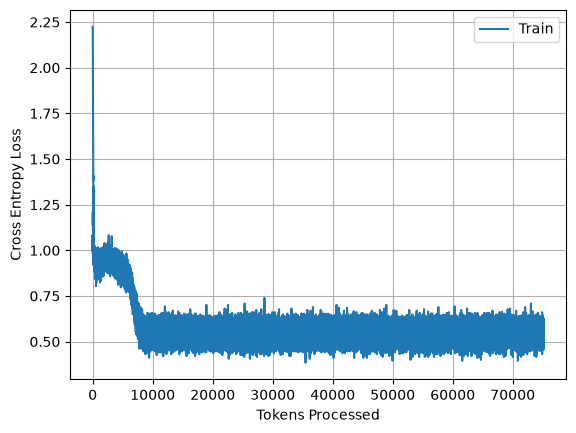

In [25]:
import matplotlib.pyplot as plt

# 1. Loss curve
plt.figure()
plt.plot(logs["iteration"], np.log(logs["train_loss"]), label="Train")

# 如果 val_loss 不是每个 iteration 都记录，
# 最好单独记录 val_iteration / val_tokens_processed
# plt.plot(logs["tokens_processed"], logs["val_loss"], label="Validation")

plt.xlabel("Tokens Processed")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

In [19]:
import json

with open("exp1_logs.json", "w") as f:
    json.dump(logs, f)

In [2]:
import json

In [3]:
with open("exp1_logs.json") as f:
    logs = json.load(f)

In [10]:

print('loading model')
run_load_checkpoint('checkpoints/75000_iteration', lm, optimizer)

loading model


74999

In [38]:

valid_data = np.memmap(
    "data/valid.bin",
    dtype=np.uint16,
    mode="r"
)

train_data = np.memmap(
    "data/train.bin",
    dtype=np.uint16,
    mode="r"
)

In [39]:
def get_checkpoint_loss(data, checkpoint_filepath, lm, optimizer):
    run_load_checkpoint(checkpoint_filepath, lm, optimizer)

    np.random.seed(42)

    
    lm.eval()
    valid_losses = []
    with torch.no_grad():
        
        for i in range(100):
            optimizer.zero_grad()
            indices, labels = run_get_batch(data, batch_size, context_length, device=device)
            output = lm.forward(indices, context_length)

            loss = run_cross_entropy(output, labels)
            valid_losses.append(loss.item())

    valid_loss = torch.tensor(valid_losses).mean()
    return valid_loss

In [40]:
x_axis = [10000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]
valid_losses = []
train_losses = []
for itr in x_axis:
    checkpoint_file = f'checkpoints/{itr}_iteration'
    mean_valid_loss = get_checkpoint_loss(valid_data, checkpoint_file, lm, optimizer)
    mean_train_loss = get_checkpoint_loss(train_data, checkpoint_file, lm, optimizer)
    valid_losses.append(mean_valid_loss)
    train_losses.append(mean_train_loss)

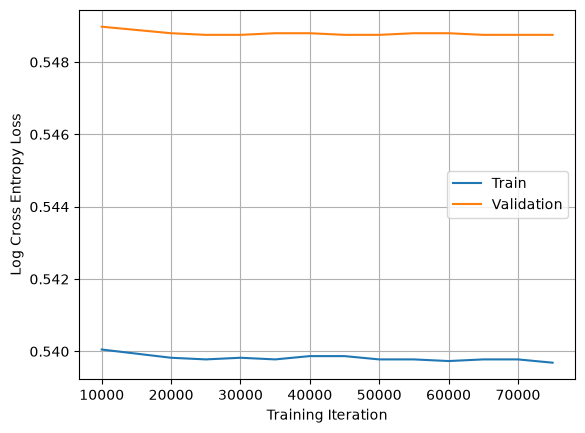

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.plot(
    x_axis,
    np.log(train_losses),
    label="Train"
)

plt.plot(
    x_axis,
    np.log(valid_losses),
    label="Validation"
)

plt.xlabel("Training Iteration")
plt.ylabel("Log Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

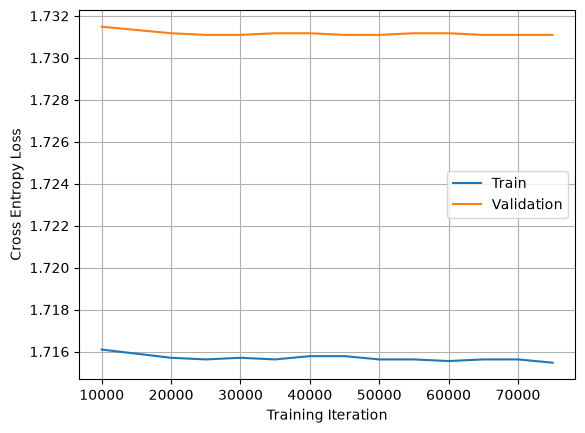

In [42]:

plt.figure()

plt.plot(
    x_axis,
    train_losses,
    label="Train"
)

plt.plot(
    x_axis,
    valid_losses,
    label="Validation"
)

plt.xlabel("Training Iteration")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()